# Denoising via Empirical Mode Decomposition (EMD)

> **Original paper**: Boudraa, A. O. & Cexus, J. C. *Denoising via Empirical Mode Decomposition*.
>
> Related work: Huang et al. (1998) EMD; Donoho & Johnstone wavelet thresholding; consecutive-MSE mode selection for EMD filtering.

This notebook reproduces the paper’s **EMD denoising** idea with PySDKit:

1. Decompose a noisy observation into IMFs + residue  
2. Preprocess IMFs (soft/hard thresholding, Savitzky–Golay, median, averaging)  
3. Reconstruct $\tilde x=\sum_j \tilde f_j + r_N$  
4. Evaluate on WaveLab-style test signals (**Doppler**, **Blocks**, **Bumps**, **Heavysine**) at SNR ≈ 2 dB  

We implement both the paper’s formulas and a **practical early-IMF** variant (noise level estimated from IMF$_1$), because applying a MAD-based universal threshold independently to *every* IMF tends to wipe out large-amplitude signal modes.


## 1. Denoising principle (paper §3)

Observation $y(t)=x(t)+b(t)$ with additive white Gaussian noise. EMD yields
$$
y(t)=\sum_{j=1}^{N}\mathrm{IMF}_j(t)+r_N(t).
$$

Model each IMF as a clean component plus noise (Eq. 2),
$$
\mathrm{IMF}_j(t)=f_j(t)+b_j(t),
$$
estimate $\tilde f_j=\Gamma[\mathrm{IMF}_j,\tau_j]$, and reconstruct (Eq. 4)
$$
\tilde x(t)=\sum_{j=1}^{N}\tilde f_j(t)+r_N(t).
$$

| Scheme | Preprocessor $\Gamma$ |
|--------|------------------------|
| EMD-Soft / EMD-Hard | nonlinear thresholding |
| EMD-SG | Savitzky–Golay ($L=3$, $w=7$) |
| EMD-Median / EMD-Average | moving median / average ($w=7$) |


## 2. Thresholding formulas (paper §3.1)

Universal threshold:
$$
\tau=\tilde\sigma\sqrt{2\log T},\qquad
\tilde\sigma=\frac{\mathrm{MAD}}{0.6745},
$$
$$
\mathrm{MAD}=\mathrm{Median}\big\{\lvert z-\mathrm{Median}\{z\}\rvert\big\}.
$$

**Soft** (Eq. 8): $\mathrm{sign}(z)\max(\lvert z\rvert-\tau,0)$.  
**Hard** (Eq. 9): keep $z$ if $\lvert z\rvert>\tau$, else 0.

**Noise-level estimation choices used in this notebook**

1. `per_imf` — paper-literal: compute $\tilde\sigma_j$ from each IMF separately  
2. `from_imf1` — wavelet-style: estimate $\tilde\sigma$ once from IMF$_1$ (finest / noisiest scale) and apply that $\tau$ only to the first $k$ IMFs; leave coarser IMFs and the residue untouched  

Option 2 is usually much closer to the qualitative behaviour reported in the paper.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.ndimage import median_filter, uniform_filter1d

from pysdkit import EMD
from pysdkit.plot import plot_IMFs

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)

RNG = np.random.default_rng(42)


def snr_db(clean, estimate):
    clean = np.asarray(clean, dtype=float)
    estimate = np.asarray(estimate, dtype=float)
    err = clean - estimate
    return float(10 * np.log10(np.sum(clean**2) / (np.sum(err**2) + 1e-16)))


def add_awgn(clean, target_snr_db, rng=None):
    rng = RNG if rng is None else rng
    clean = np.asarray(clean, dtype=float)
    p_sig = np.mean(clean**2)
    p_noise = p_sig / (10 ** (target_snr_db / 10.0))
    return clean + rng.normal(0.0, np.sqrt(p_noise), size=clean.shape)


def mad_sigma(x):
    x = np.asarray(x, dtype=float)
    return float(np.median(np.abs(x - np.median(x))) / 0.6745)


def universal_threshold(sigma, T):
    return float(sigma * np.sqrt(2.0 * np.log(T)))


def soft_threshold(x, tau):
    return np.sign(x) * np.maximum(np.abs(x) - tau, 0.0)


def hard_threshold(x, tau):
    y = np.array(x, copy=True, dtype=float)
    y[np.abs(y) <= tau] = 0.0
    return y


def cmse_change_index(imfs, residue):
    # Blind index k minimizing consecutive MSE of partial reconstructions.
    # recon_k = sum_{j=k..N-1} IMF_j + residue  (0-based k)
    n = imfs.shape[0]
    if n < 2:
        return 0
    partial = []
    for k in range(n):
        partial.append(imfs[k:].sum(axis=0) + residue)
    cmses = []
    for k in range(n - 1):
        cmses.append(np.mean((partial[k] - partial[k + 1]) ** 2))
    return int(np.argmin(cmses))  # threshold / discard IMFs 0..k


def emd_denoise(
    noisy,
    method="soft",
    noise_rule="from_imf1",
    n_noise_imfs=None,
    window=7,
    polyorder=3,
    max_imfs=-1,
):
    # method: soft | hard | sg | median | average | none
    # noise_rule:
    #   per_imf   -> paper-literal MAD per IMF
    #   from_imf1 -> sigma from IMF1; process only first n_noise_imfs
    #   cmse      -> choose n_noise_imfs by consecutive-MSE index
    emd = EMD(max_imfs=max_imfs)
    _ = emd.fit_transform(noisy)
    imfs, residue = emd.get_imfs_and_residue()
    T = len(noisy)
    n_imfs = imfs.shape[0]

    if n_noise_imfs is None:
        if noise_rule == "cmse":
            n_noise_imfs = cmse_change_index(imfs, residue) + 1
        elif noise_rule == "from_imf1":
            n_noise_imfs = max(1, min(4, n_imfs // 2 + 1))
        else:
            n_noise_imfs = n_imfs
    n_noise_imfs = int(np.clip(n_noise_imfs, 0, n_imfs))

    sigma1 = mad_sigma(imfs[0]) if n_imfs else 0.0
    tau1 = universal_threshold(sigma1, T)

    cleaned = np.zeros_like(imfs)
    thresholds = np.full(n_imfs, np.nan)
    for j in range(n_imfs):
        c = imfs[j]
        process = (noise_rule == "per_imf") or (j < n_noise_imfs)
        if not process or method == "none":
            cleaned[j] = c
            thresholds[j] = 0.0
            continue

        if method in ("soft", "hard"):
            if noise_rule == "per_imf":
                tau = universal_threshold(mad_sigma(c), T)
            else:
                tau = tau1
            thresholds[j] = tau
            cleaned[j] = (
                soft_threshold(c, tau) if method == "soft" else hard_threshold(c, tau)
            )
        elif method == "sg":
            w = window if window % 2 == 1 else window + 1
            w = min(w, len(c) - (1 - len(c) % 2))
            cleaned[j] = c if w < polyorder + 2 else savgol_filter(c, w, polyorder)
        elif method == "median":
            cleaned[j] = median_filter(c, size=window, mode="nearest")
        elif method == "average":
            cleaned[j] = uniform_filter1d(c, size=window, mode="nearest")
        else:
            raise ValueError("Unknown method")

    recon = cleaned.sum(axis=0) + residue
    return {
        "imfs": imfs,
        "residue": residue,
        "imfs_clean": cleaned,
        "thresholds": thresholds,
        "n_noise_imfs": n_noise_imfs,
        "sigma1": sigma1,
        "recon": recon,
    }


## 3. Classical test signals (WaveLab / Donoho–Johnstone)

Paper §4: Doppler, Blocks, Bumps, Heavysine with $T=2048$.


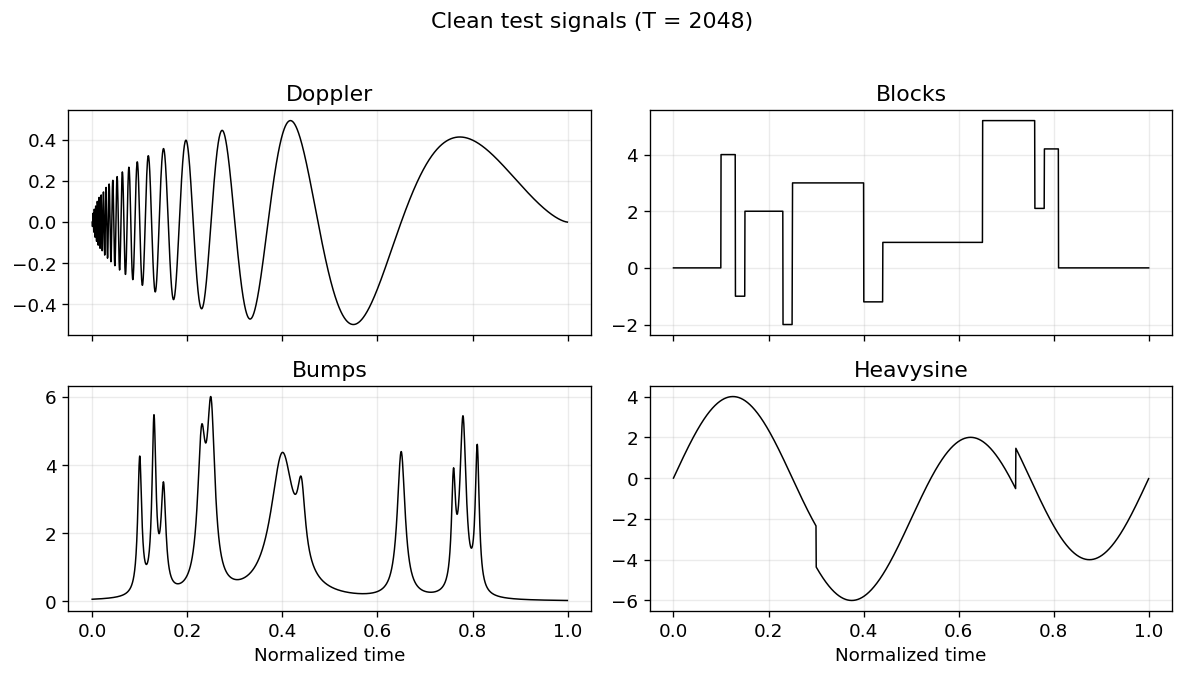

In [2]:
def make_doppler(n=2048):
    t = np.arange(n) / n
    x = np.sqrt(t * (1 - t)) * np.sin((2 * np.pi * 1.05) / (t + 0.05))
    return t, x


def make_blocks(n=2048):
    t = np.arange(n) / n
    pos = np.array([0.1, 0.13, 0.15, 0.23, 0.25, 0.40, 0.44, 0.65, 0.76, 0.78, 0.81])
    hgt = np.array([4, -5, 3, -4, 5, -4.2, 2.1, 4.3, -3.1, 2.1, -4.2])
    x = np.zeros(n)
    for p, h in zip(pos, hgt):
        x += (h / 2.0) * (1 + np.sign(t - p))
    return t, x


def make_bumps(n=2048):
    t = np.arange(n) / n
    pos = np.array([0.1, 0.13, 0.15, 0.23, 0.25, 0.40, 0.44, 0.65, 0.76, 0.78, 0.81])
    hgt = np.array([4, 5, 3, 4, 5, 4.2, 2.1, 4.3, 3.1, 5.1, 4.2])
    wth = np.array(
        [0.005, 0.005, 0.006, 0.01, 0.01, 0.03, 0.01, 0.01, 0.005, 0.008, 0.005]
    )
    x = np.zeros(n)
    for p, h, w in zip(pos, hgt, wth):
        x += h / (1.0 + ((t - p) / w) ** 2)
    return t, x


def make_heavisine(n=2048):
    t = np.arange(n) / n
    x = 4 * np.sin(4 * np.pi * t) - np.sign(t - 0.3) - np.sign(0.72 - t)
    return t, x


SIGNALS = {
    "Doppler": make_doppler,
    "Blocks": make_blocks,
    "Bumps": make_bumps,
    "Heavysine": make_heavisine,
}

fig, axs = plt.subplots(2, 2, figsize=(10, 5.5), sharex=True)
for ax, name in zip(axs.ravel(), SIGNALS):
    t, x = SIGNALS[name]()
    ax.plot(t, x, "k", lw=0.9)
    ax.set_title(name)
axs[1, 0].set_xlabel("Normalized time")
axs[1, 1].set_xlabel("Normalized time")
plt.suptitle("Clean test signals (T = 2048)", y=1.02)
plt.tight_layout()
plt.show()

## 4. Corrupt with AWGN at SNR ≈ 2 dB


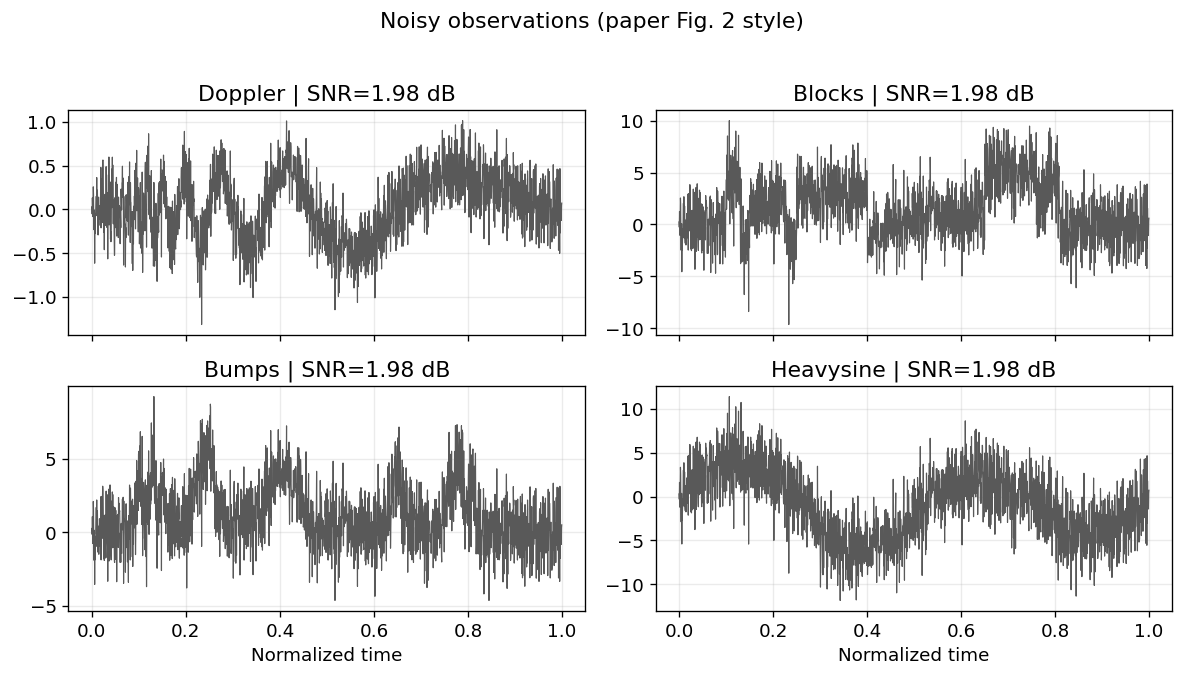

In [3]:
TARGET_SNR = 2.0
clean, noisy = {}, {}

fig, axs = plt.subplots(2, 2, figsize=(10, 5.5), sharex=True)
for ax, name in zip(axs.ravel(), SIGNALS):
    t, x = SIGNALS[name]()
    y = add_awgn(x, TARGET_SNR, rng=np.random.default_rng(0))
    clean[name], noisy[name] = x, y
    ax.plot(t, y, color="0.35", lw=0.7)
    ax.set_title(f"{name} | SNR={snr_db(x, y):.2f} dB")
axs[1, 0].set_xlabel("Normalized time")
axs[1, 1].set_xlabel("Normalized time")
plt.suptitle("Noisy observations (paper Fig. 2 style)", y=1.02)
plt.tight_layout()
plt.show()

## 5. Step-by-step on **Bumps**

Decompose → estimate $\tau$ from IMF$_1$ → soft-threshold early IMFs → reconstruct.


IMFs: 8 | noise IMFs processed: 4
sigma_hat(IMF1)=1.5173, tau=5.9249
input SNR : 1.98 dB
EMD-Soft  : 13.11 dB


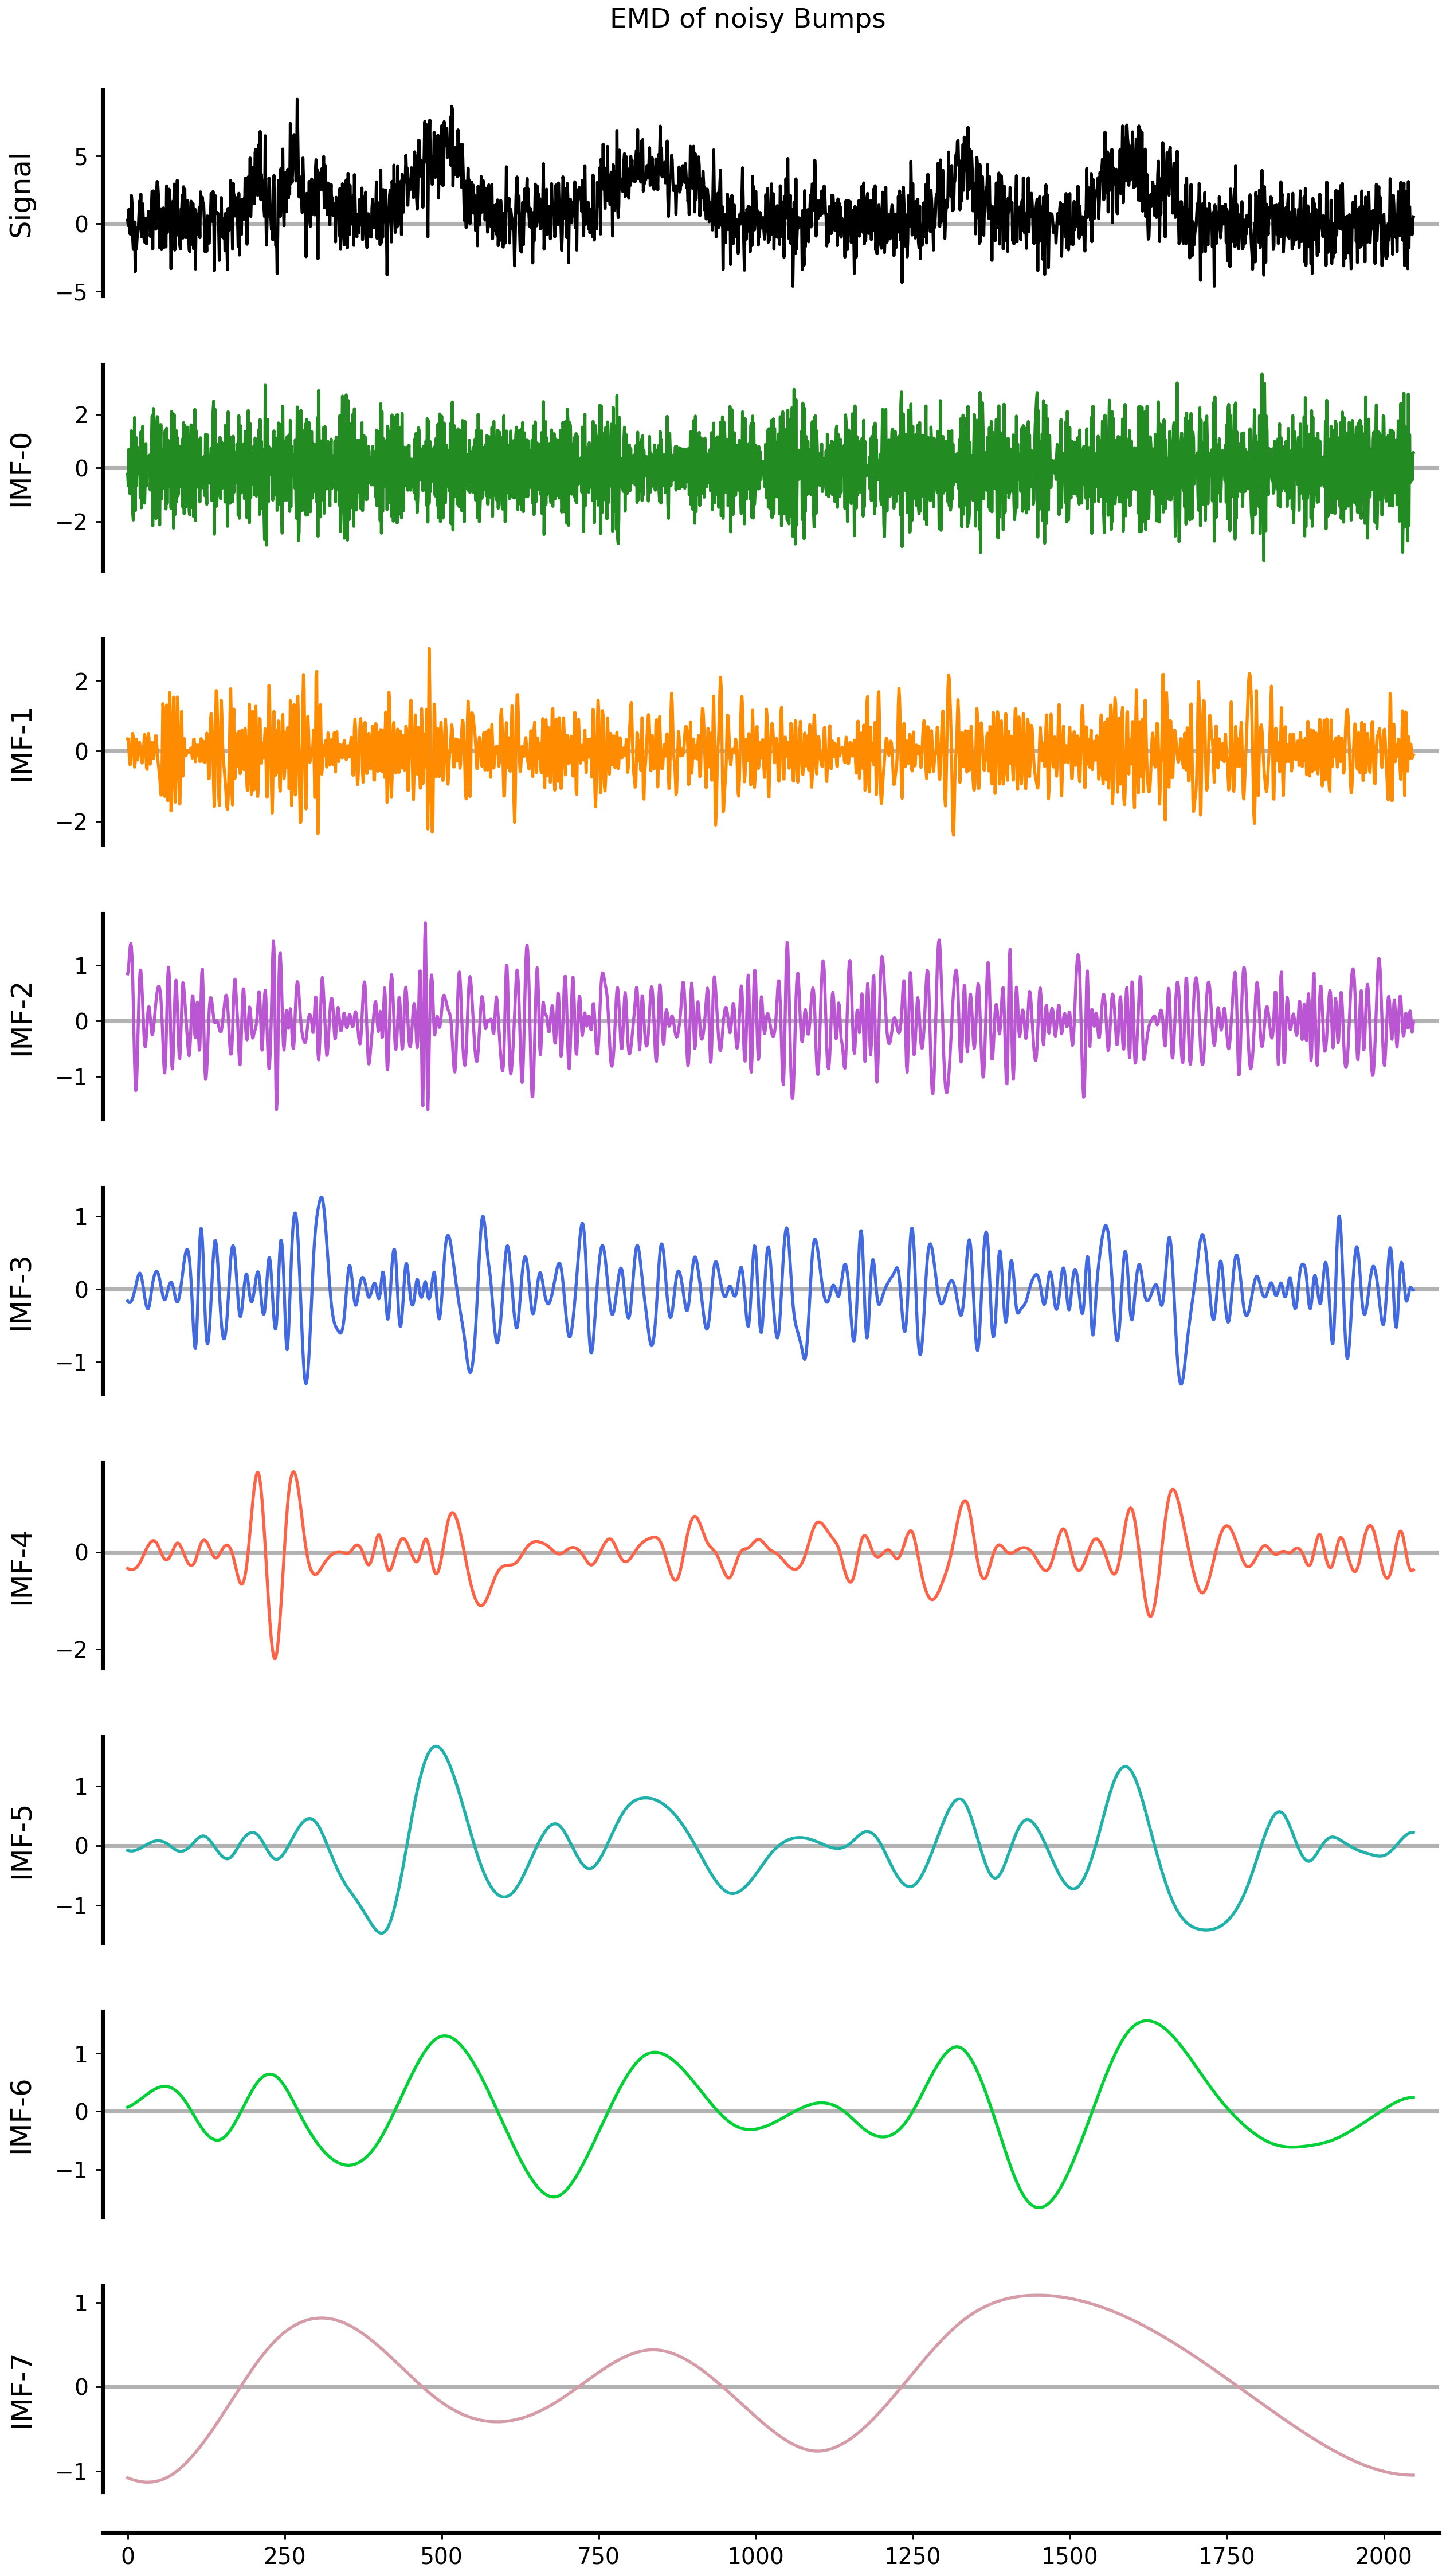

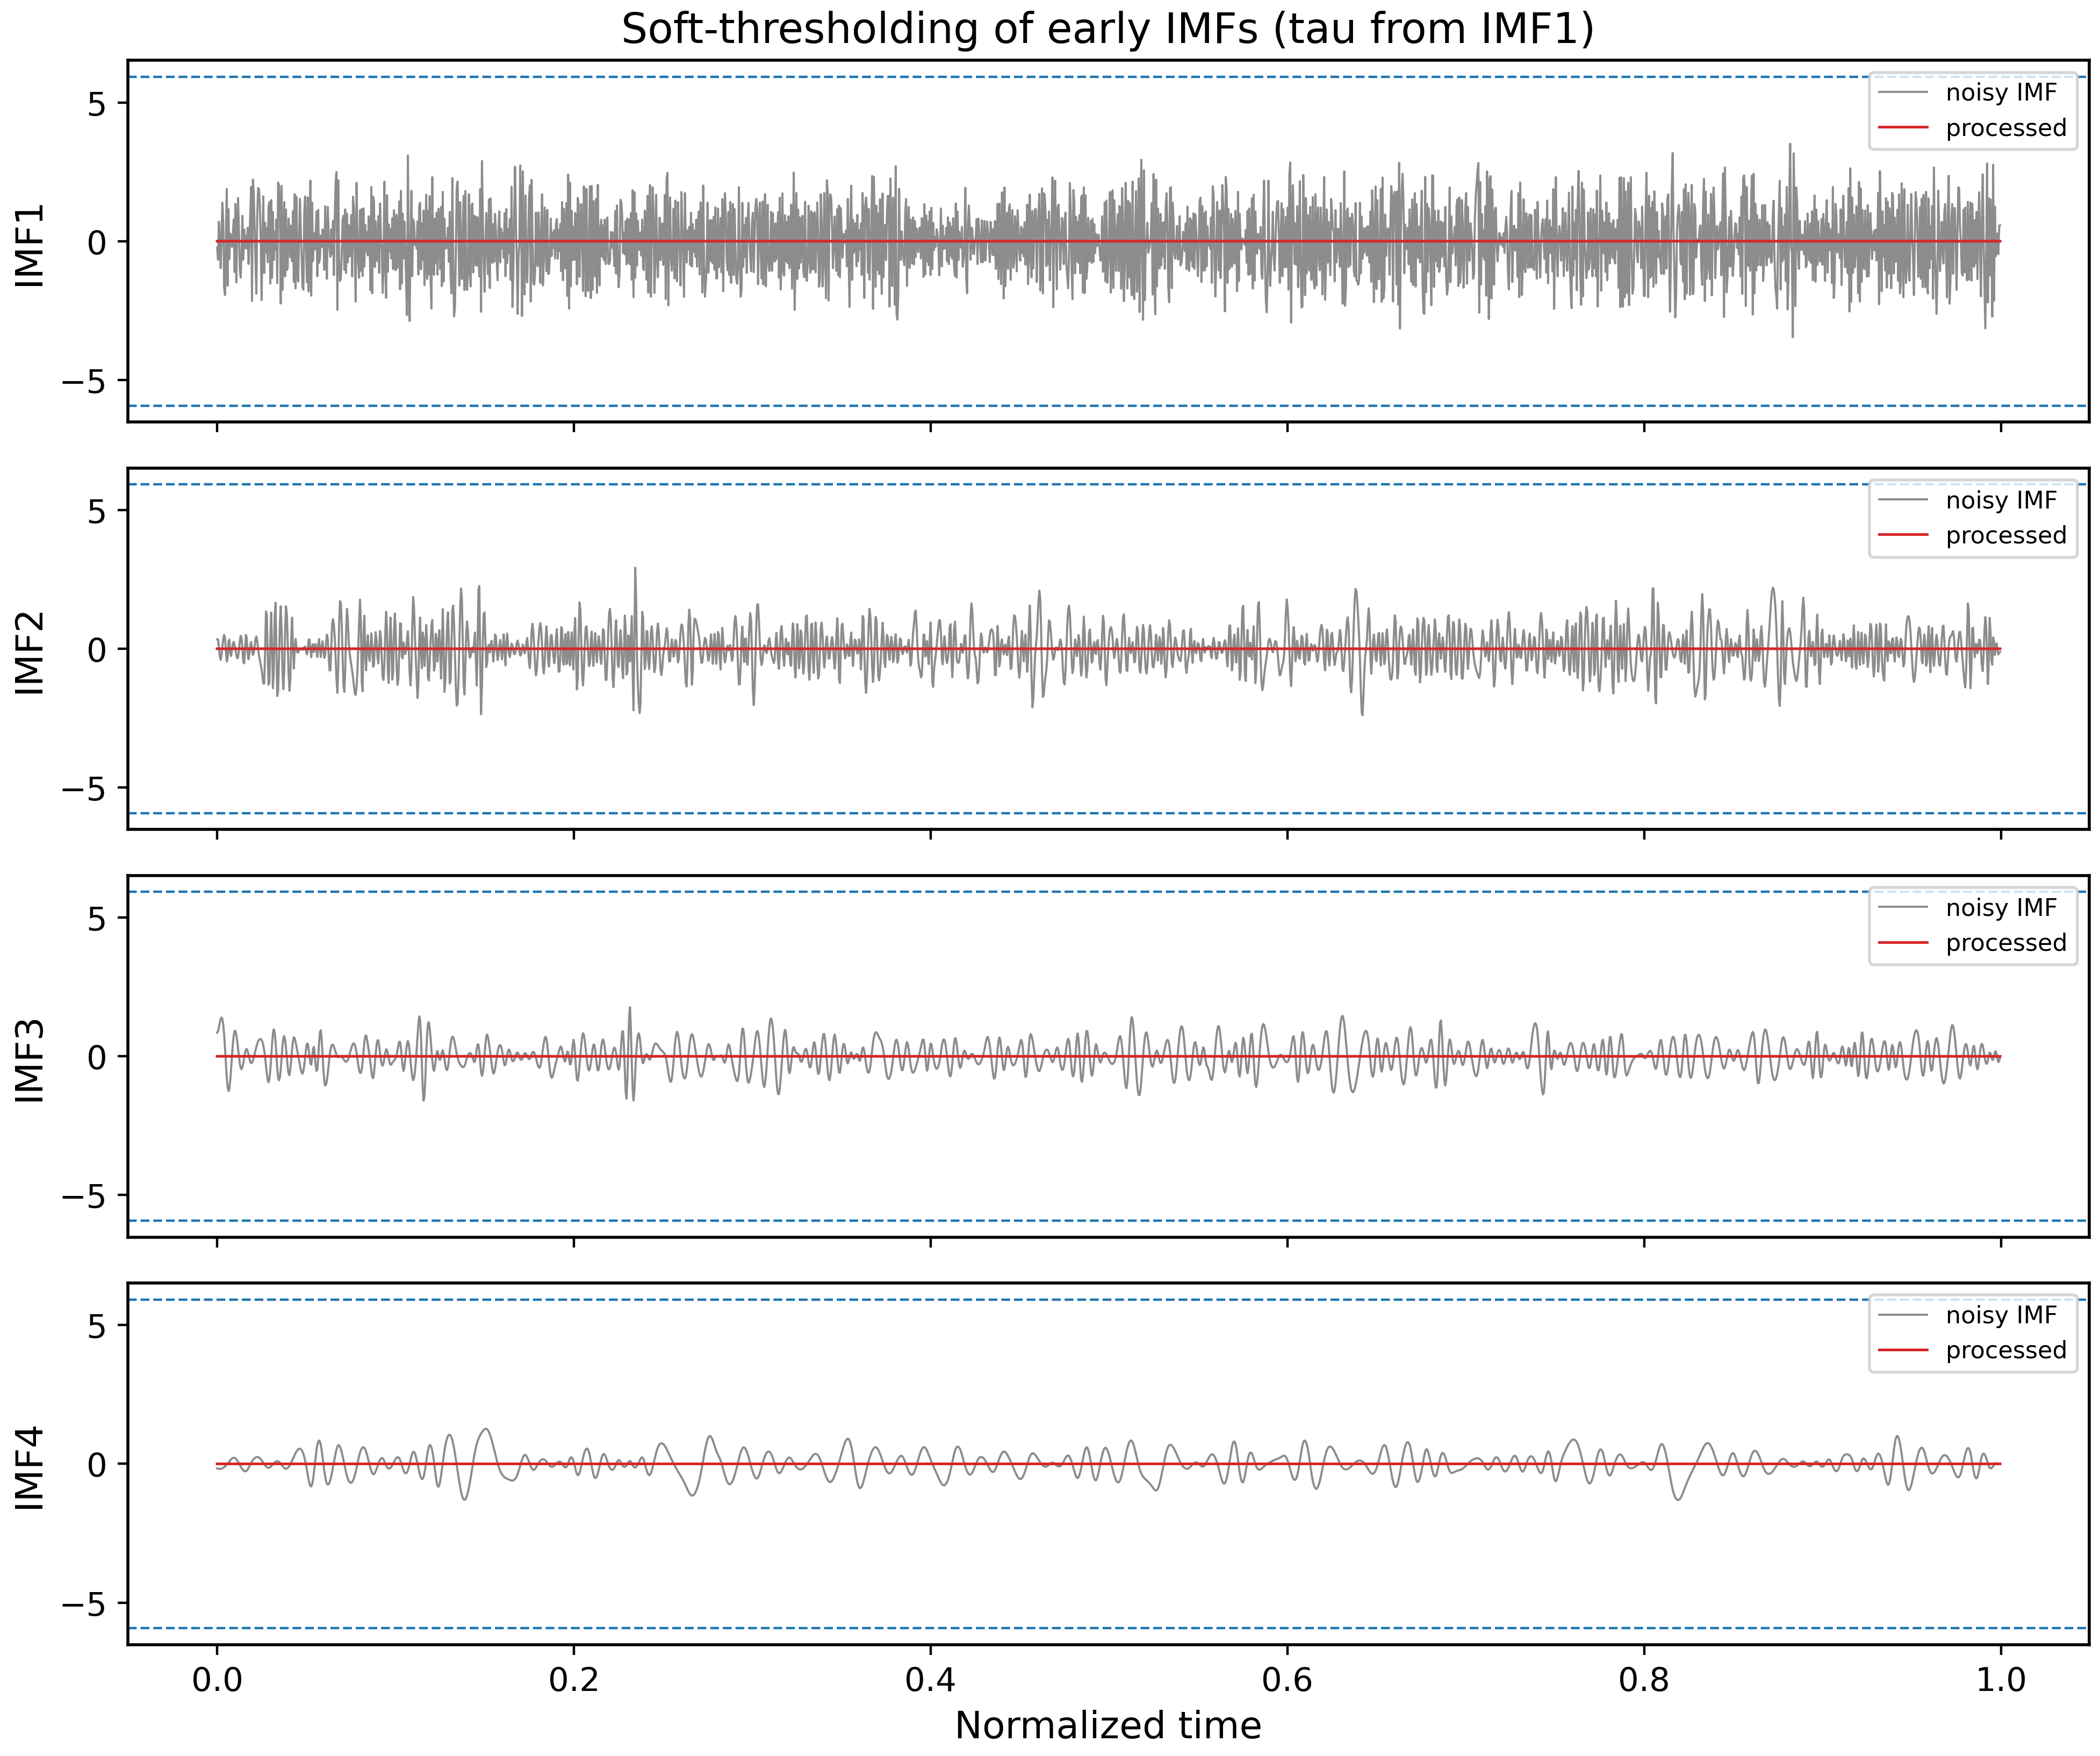

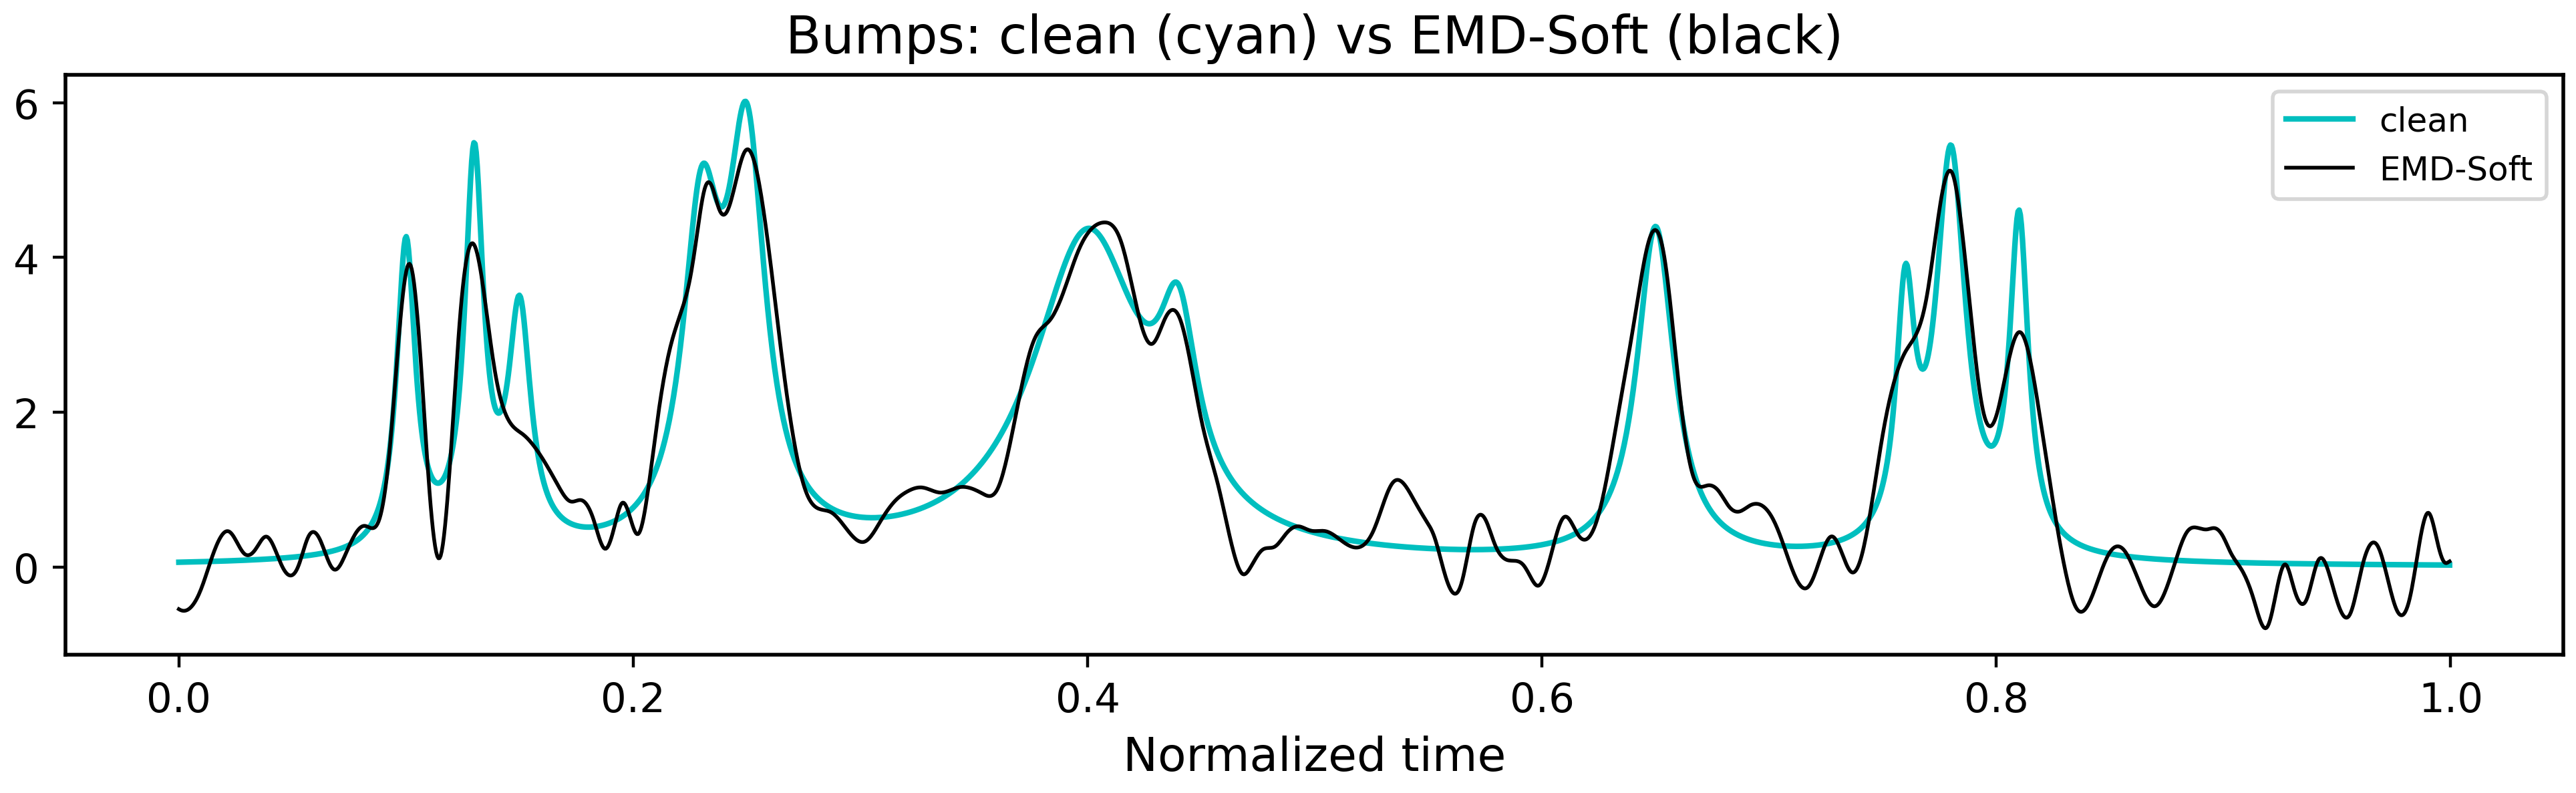

paper per-imf MAD soft: 3.17 dB
CMSE-selected early soft: 13.11 dB (k=4)


In [4]:
name = "Bumps"
t = np.arange(2048) / 2048.0
x, y = clean[name], noisy[name]

out = emd_denoise(y, method="soft", noise_rule="from_imf1", n_noise_imfs=4)
imfs = out["imfs"]
print("IMFs:", imfs.shape[0], "| noise IMFs processed:", out["n_noise_imfs"])
print(
    f"sigma_hat(IMF1)={out['sigma1']:.4f}, tau={universal_threshold(out['sigma1'], len(y)):.4f}"
)
print("input SNR :", f"{snr_db(x, y):.2f} dB")
print("EMD-Soft  :", f"{snr_db(x, out['recon']):.2f} dB")

fig = plot_IMFs(y, imfs, return_figure=True)
plt.suptitle("EMD of noisy Bumps", y=1.02)
plt.show()

n_show = min(4, imfs.shape[0])
fig, axs = plt.subplots(n_show, 1, figsize=(10, 2.1 * n_show), sharex=True)
if n_show == 1:
    axs = [axs]
for j in range(n_show):
    tau = out["thresholds"][j]
    axs[j].plot(t, imfs[j], color="0.55", lw=0.7, label="noisy IMF")
    axs[j].plot(t, out["imfs_clean"][j], color="C3", lw=0.9, label="processed")
    if np.isfinite(tau) and tau > 0:
        axs[j].axhline(tau, color="C0", ls="--", lw=0.8)
        axs[j].axhline(-tau, color="C0", ls="--", lw=0.8)
    axs[j].set_ylabel(f"IMF{j+1}")
    axs[j].legend(fontsize=8, loc="upper right")
axs[0].set_title("Soft-thresholding of early IMFs (tau from IMF1)")
axs[-1].set_xlabel("Normalized time")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(t, x, color="c", lw=1.5, label="clean")
ax.plot(t, out["recon"], "k", lw=1.0, label="EMD-Soft")
ax.legend(fontsize=9)
ax.set_title("Bumps: clean (cyan) vs EMD-Soft (black)")
ax.set_xlabel("Normalized time")
plt.tight_layout()
plt.show()

# Compare paper-literal per-IMF MAD vs from_imf1
out_lit = emd_denoise(y, method="soft", noise_rule="per_imf")
out_cmse = emd_denoise(y, method="soft", noise_rule="cmse")
print("paper per-imf MAD soft:", f"{snr_db(x, out_lit['recon']):.2f} dB")
print(
    "CMSE-selected early soft:",
    f"{snr_db(x, out_cmse['recon']):.2f} dB",
    f"(k={out_cmse['n_noise_imfs']})",
)

## 6. Method comparison (paper Table I style)

Default: `noise_rule='from_imf1'` with the first 4 IMFs preprocessed; SG/Median/Average use $w=7$, $L=3$.


In [5]:
METHODS = ["soft", "hard", "sg", "median", "average"]
LABEL = {
    "soft": "EMD-Soft",
    "hard": "EMD-Hard",
    "sg": "EMD-SG",
    "median": "EMD-Median",
    "average": "EMD-Average",
}

results = {m: {} for m in METHODS}
recons = {m: {} for m in METHODS}

for name in SIGNALS:
    x, y = clean[name], noisy[name]
    print("===", name, "input", f"{snr_db(x, y):.2f}", "dB")
    for m in METHODS:
        out = emd_denoise(
            y, method=m, noise_rule="from_imf1", n_noise_imfs=4, window=7, polyorder=3
        )
        s = snr_db(x, out["recon"])
        results[m][name] = s
        recons[m][name] = out["recon"]
        print(f"  {LABEL[m]:12s}: {s:6.2f} dB")

header = f"{'Method':14s}" + "".join(f"{n:>12s}" for n in SIGNALS)
print("\n" + header)
print("-" * len(header))
print(
    f"{'Noise':14s}" + "".join(f"{snr_db(clean[n], noisy[n]):12.2f}" for n in SIGNALS)
)
for m in METHODS:
    print(f"{LABEL[m]:14s}" + "".join(f"{results[m][n]:12.2f}" for n in SIGNALS))

print("\nPaper Table I (reference, dB):")
print("Noise      2.03 / 2.03 / 2.03 / 2.03")
print("EMD-Soft  11.13 / 11.98 / 19.86 / 11.18")
print("EMD-SG    13.57 / 12.00 / 20.60 / 14.50")
print(
    "(Exact numbers differ with EMD implementation / boundaries; trends should be similar.)"
)

=== Doppler input 1.98 dB
  EMD-Soft    :  12.02 dB
  EMD-Hard    :  12.02 dB
  EMD-SG      :   6.82 dB
  EMD-Median  :   7.63 dB
  EMD-Average :  10.28 dB
=== Blocks input 1.98 dB
  EMD-Soft    :  11.57 dB
  EMD-Hard    :  11.57 dB
  EMD-SG      :   6.77 dB
  EMD-Median  :   7.61 dB
  EMD-Average :  10.07 dB
=== Bumps input 1.98 dB
  EMD-Soft    :  13.11 dB
  EMD-Hard    :  13.11 dB
  EMD-SG      :   6.82 dB
  EMD-Median  :   7.82 dB
  EMD-Average :  10.39 dB
=== Heavysine input 1.98 dB
  EMD-Soft    :  14.96 dB
  EMD-Hard    :  14.96 dB
  EMD-SG      :   6.82 dB
  EMD-Median  :   7.80 dB
  EMD-Average :  10.39 dB

Method             Doppler      Blocks       Bumps   Heavysine
--------------------------------------------------------------
Noise                 1.98        1.98        1.98        1.98
EMD-Soft             12.02       11.57       13.11       14.96
EMD-Hard             12.02       11.57       13.11       14.96
EMD-SG                6.82        6.77        6.82        6.8

## 7. Visual reconstructions (paper Fig. 3 style)

Cyan = clean reference, black = denoised estimate.


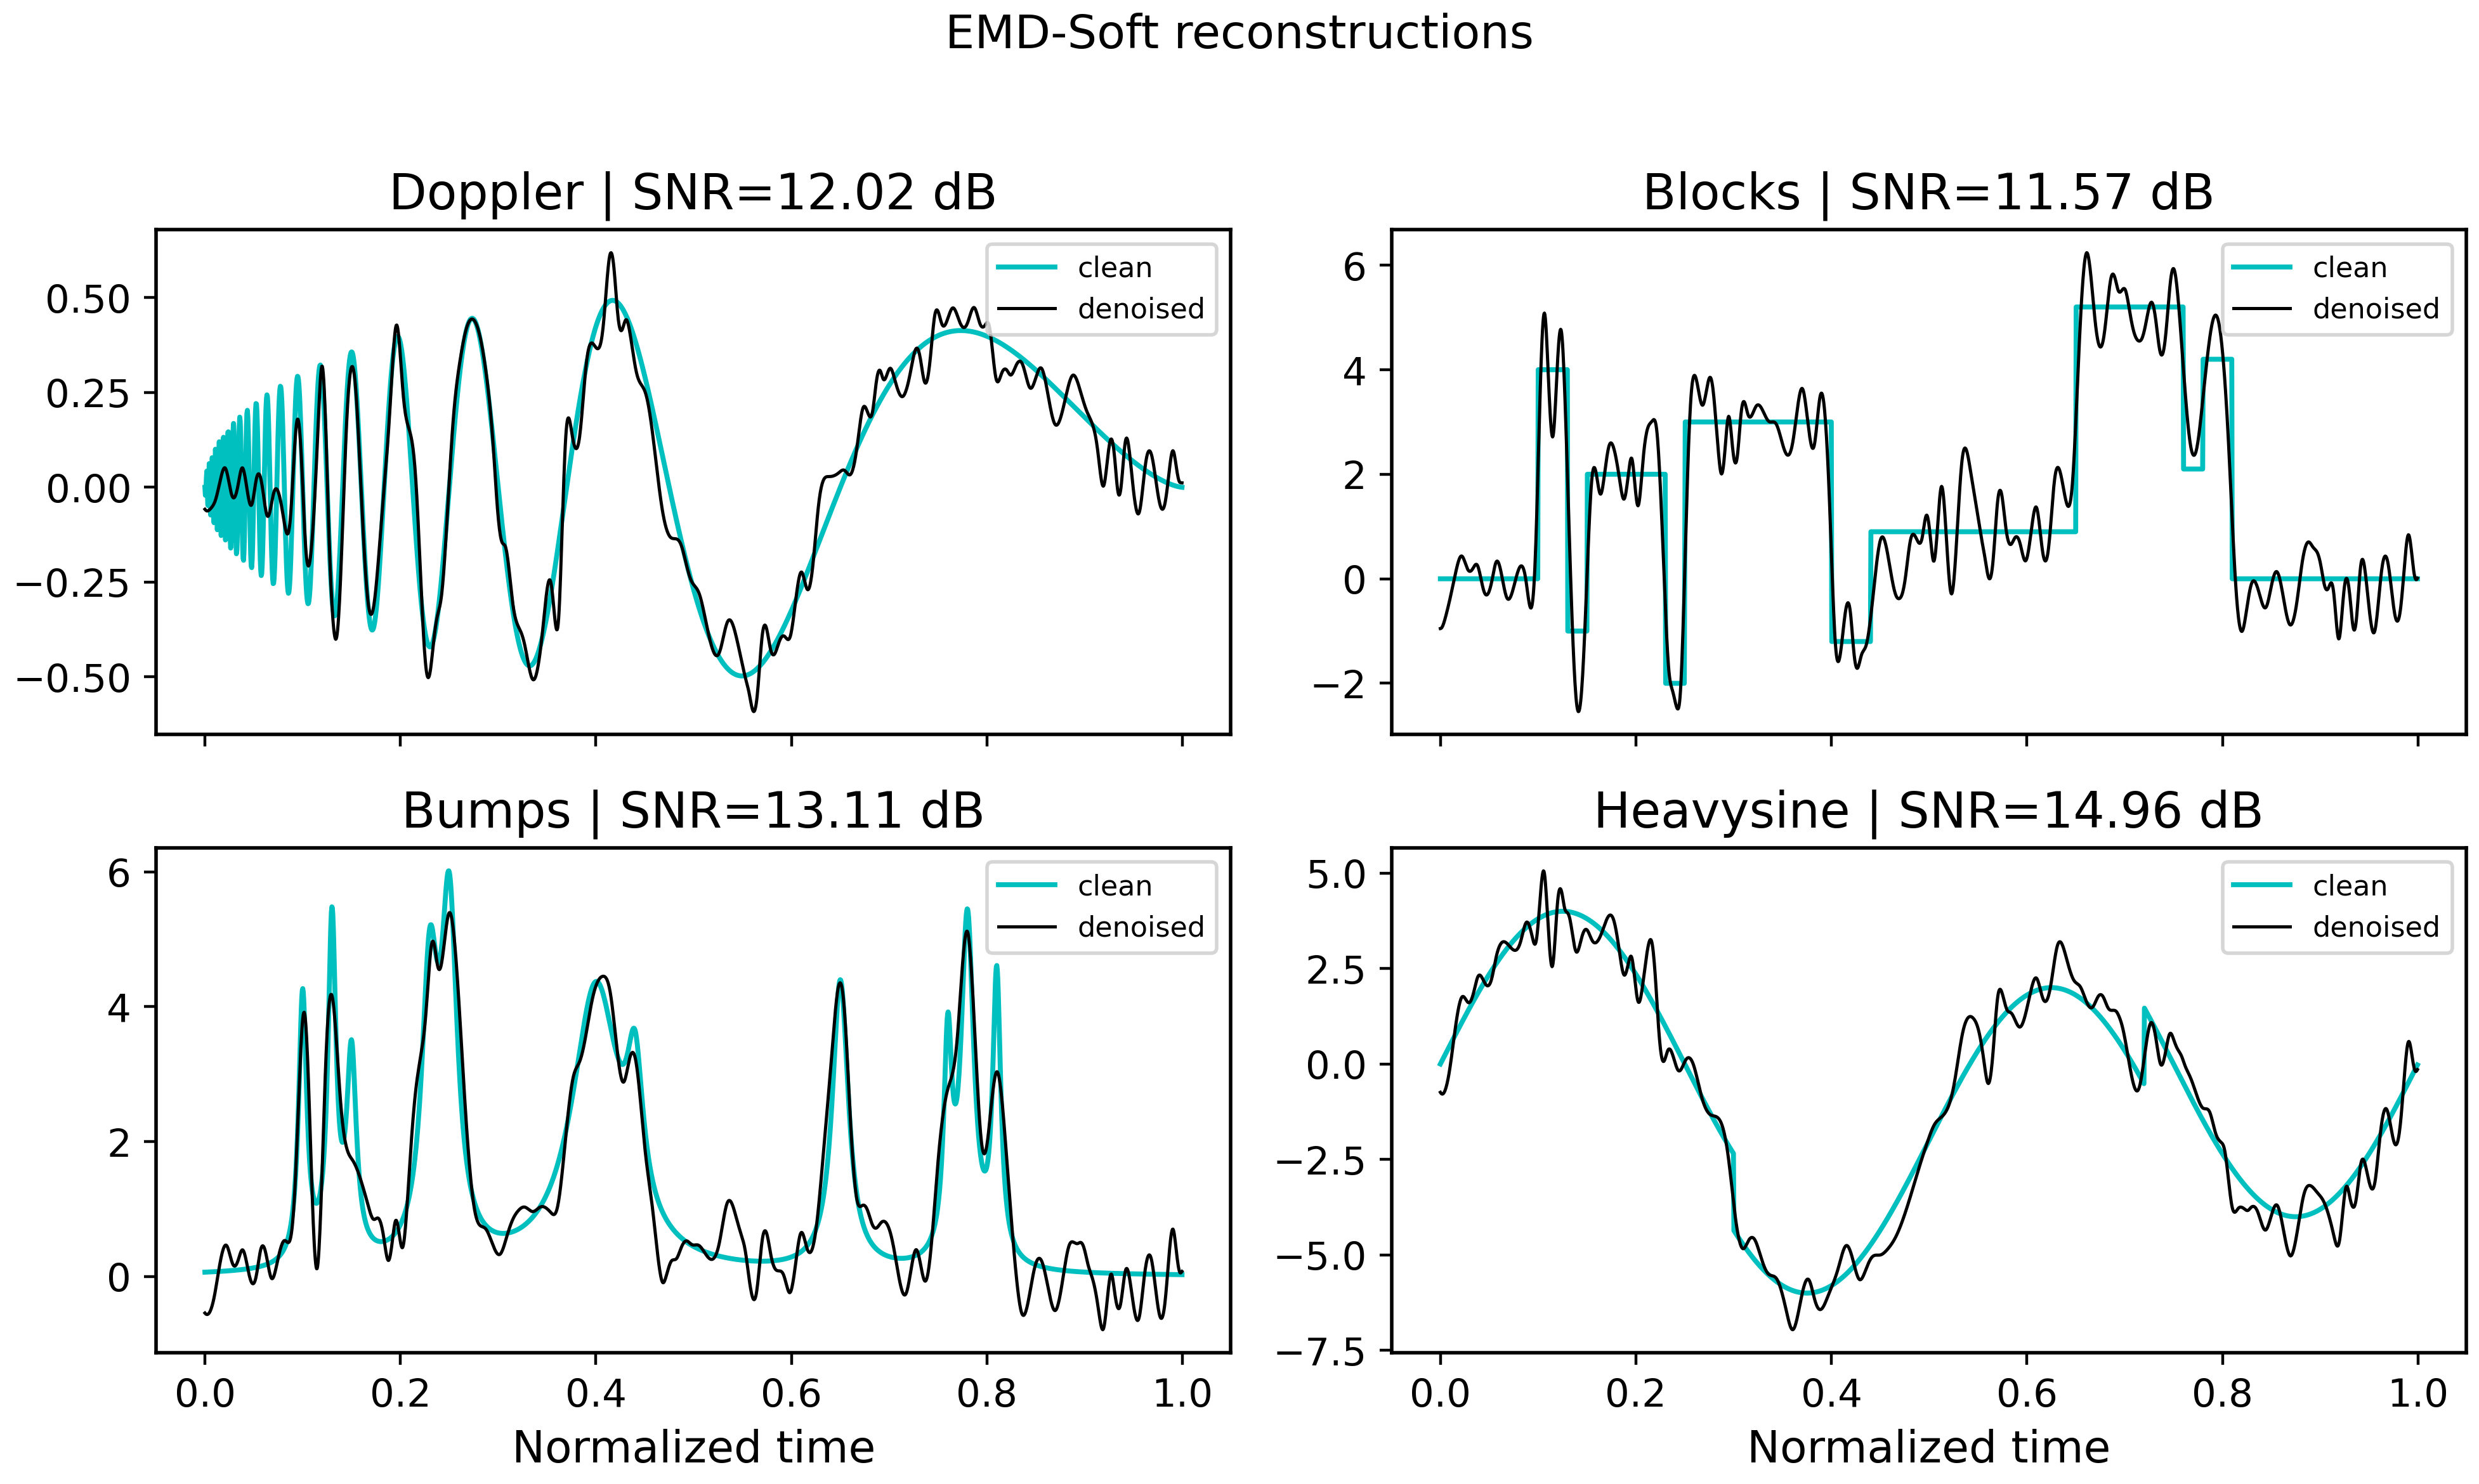

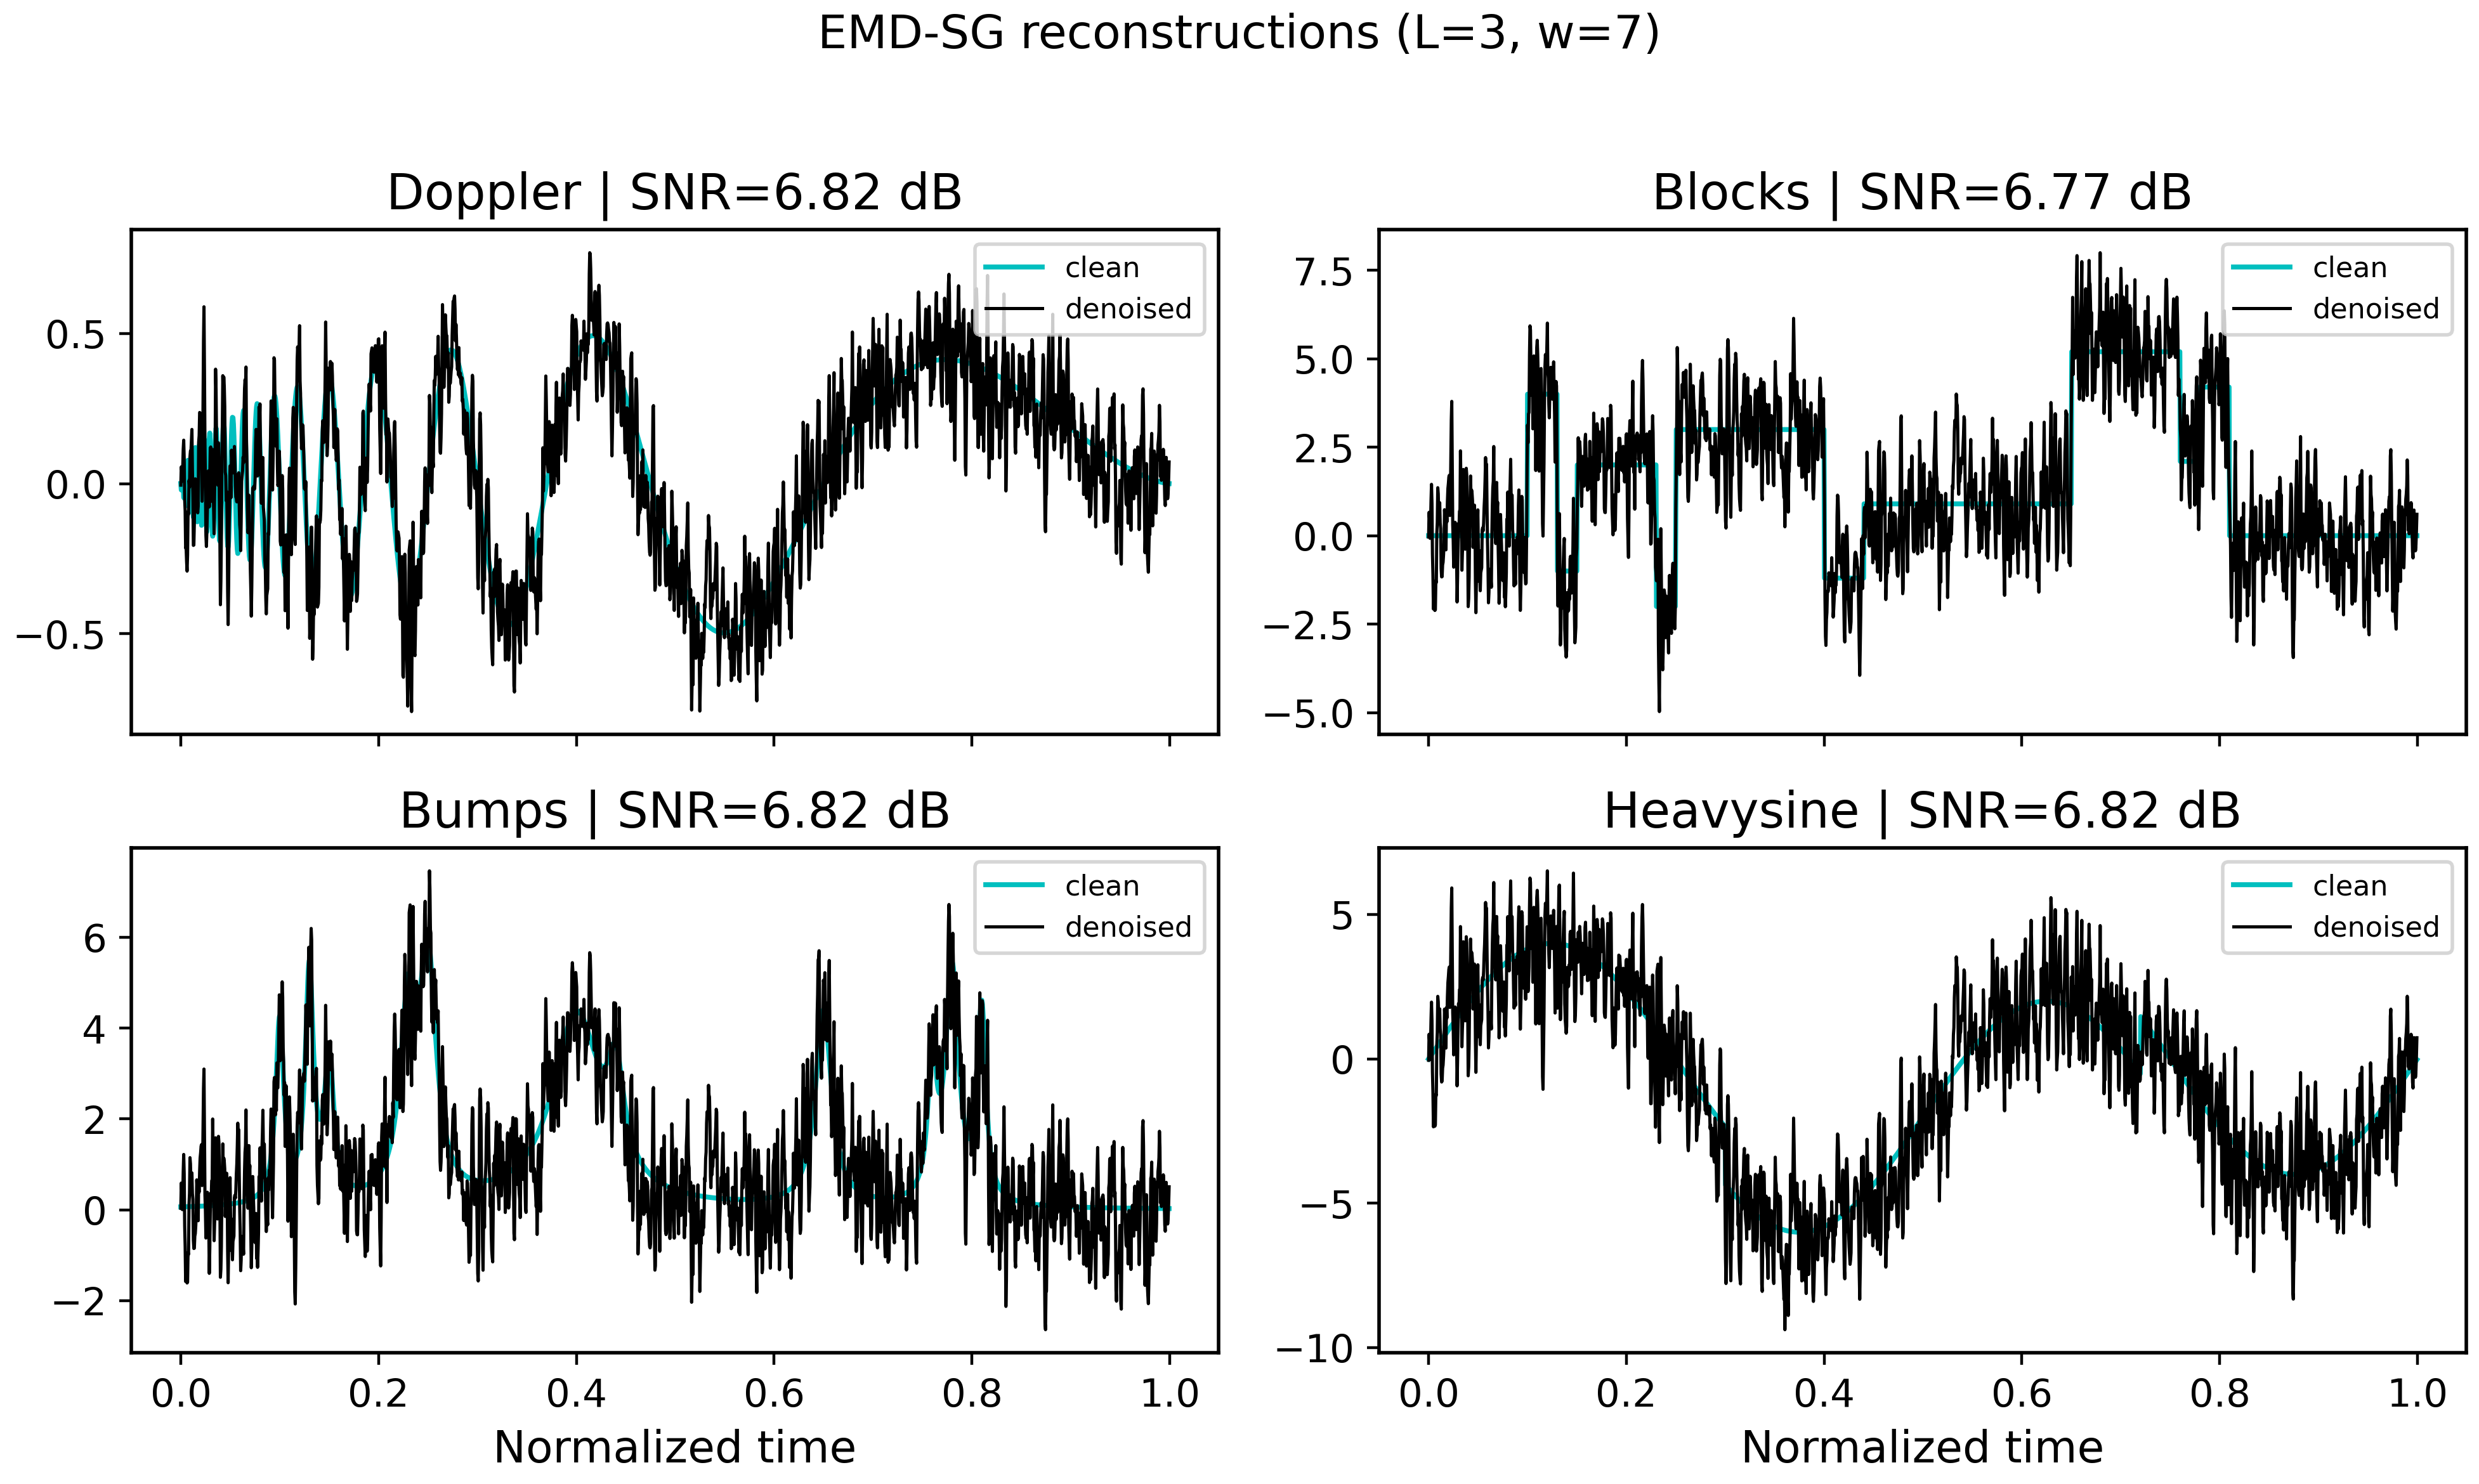

In [6]:
def show_recon_grid(method_key, title):
    fig, axs = plt.subplots(2, 2, figsize=(10, 5.8), sharex=True)
    for ax, name in zip(axs.ravel(), SIGNALS):
        tt = np.arange(len(clean[name])) / len(clean[name])
        ax.plot(tt, clean[name], color="c", lw=1.4, label="clean")
        ax.plot(tt, recons[method_key][name], "k", lw=0.9, label="denoised")
        ax.set_title(f"{name} | SNR={results[method_key][name]:.2f} dB")
        ax.legend(fontsize=8, loc="upper right")
    axs[1, 0].set_xlabel("Normalized time")
    axs[1, 1].set_xlabel("Normalized time")
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


show_recon_grid("soft", "EMD-Soft reconstructions")
show_recon_grid("sg", "EMD-SG reconstructions (L=3, w=7)")

## 8. Noise-level sweep on Bumps (paper Fig. 4)

Horizontal axis: $\sqrt{\mathrm{SNR}_{\mathrm{linear}}}$ (paper: 0.2 → 5), i.e. input SNR in dB is $20\log_{10}(\cdot)$.


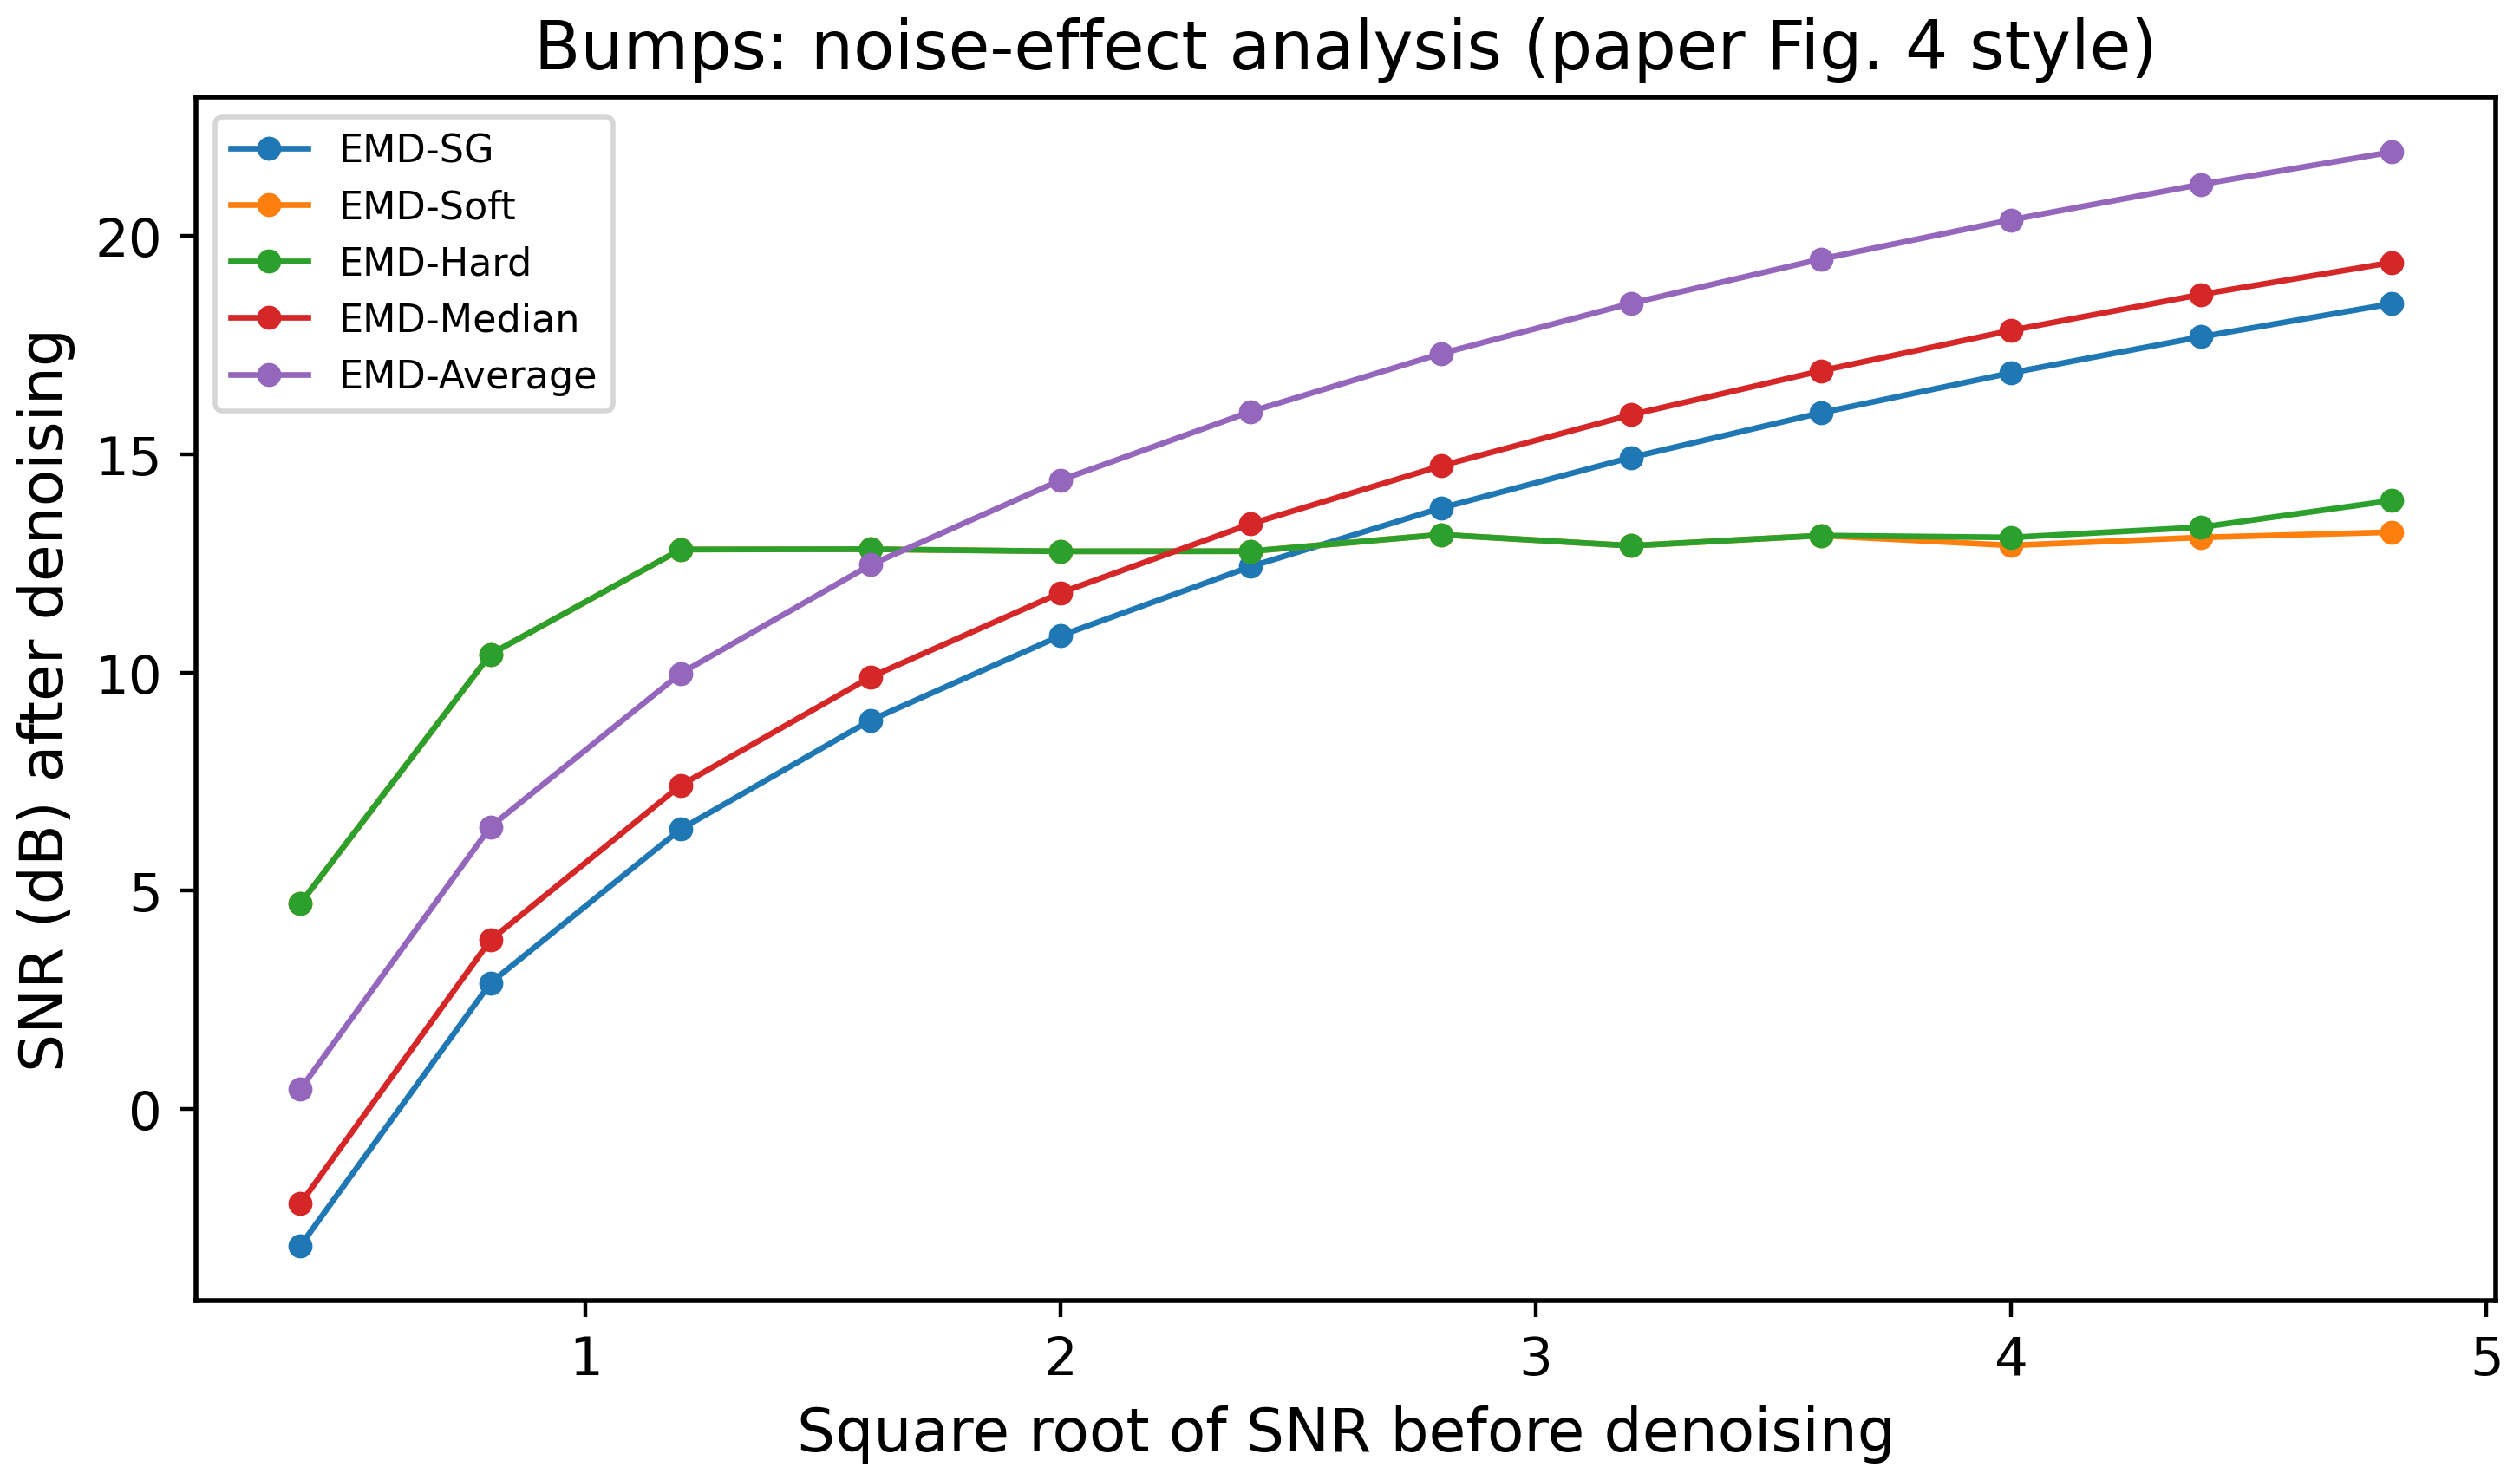

In [7]:
sqrt_snr_grid = np.arange(0.4, 5.01, 0.4)
curve_names = ["EMD-SG", "EMD-Soft", "EMD-Hard", "EMD-Median", "EMD-Average"]
method_map = {
    "EMD-SG": "sg",
    "EMD-Soft": "soft",
    "EMD-Hard": "hard",
    "EMD-Median": "median",
    "EMD-Average": "average",
}
curves = {k: [] for k in curve_names}
x_b = clean["Bumps"]

for sroot in sqrt_snr_grid:
    snr_db_in = 20.0 * np.log10(sroot)
    y_b = add_awgn(x_b, snr_db_in, rng=np.random.default_rng(0))
    for label, m in method_map.items():
        out = emd_denoise(
            y_b, method=m, noise_rule="from_imf1", n_noise_imfs=4, window=7, polyorder=3
        )
        curves[label].append(snr_db(x_b, out["recon"]))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for label, vals in curves.items():
    ax.plot(sqrt_snr_grid, vals, "o-", lw=1.2, ms=4, label=label)
ax.set_xlabel("Square root of SNR before denoising")
ax.set_ylabel("SNR (dB) after denoising")
ax.set_title("Bumps: noise-effect analysis (paper Fig. 4 style)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. ECG-style example (paper: SNR ≈ −9 dB)

The original clinical ECG file is not bundled here; we use a synthetic multi-beat ECG-like waveform under the same SNR condition.


ECG-like input SNR:  -9.06 dB
EMD-Soft output SNR: 1.32 dB
EMD-SG   output SNR: -4.29 dB


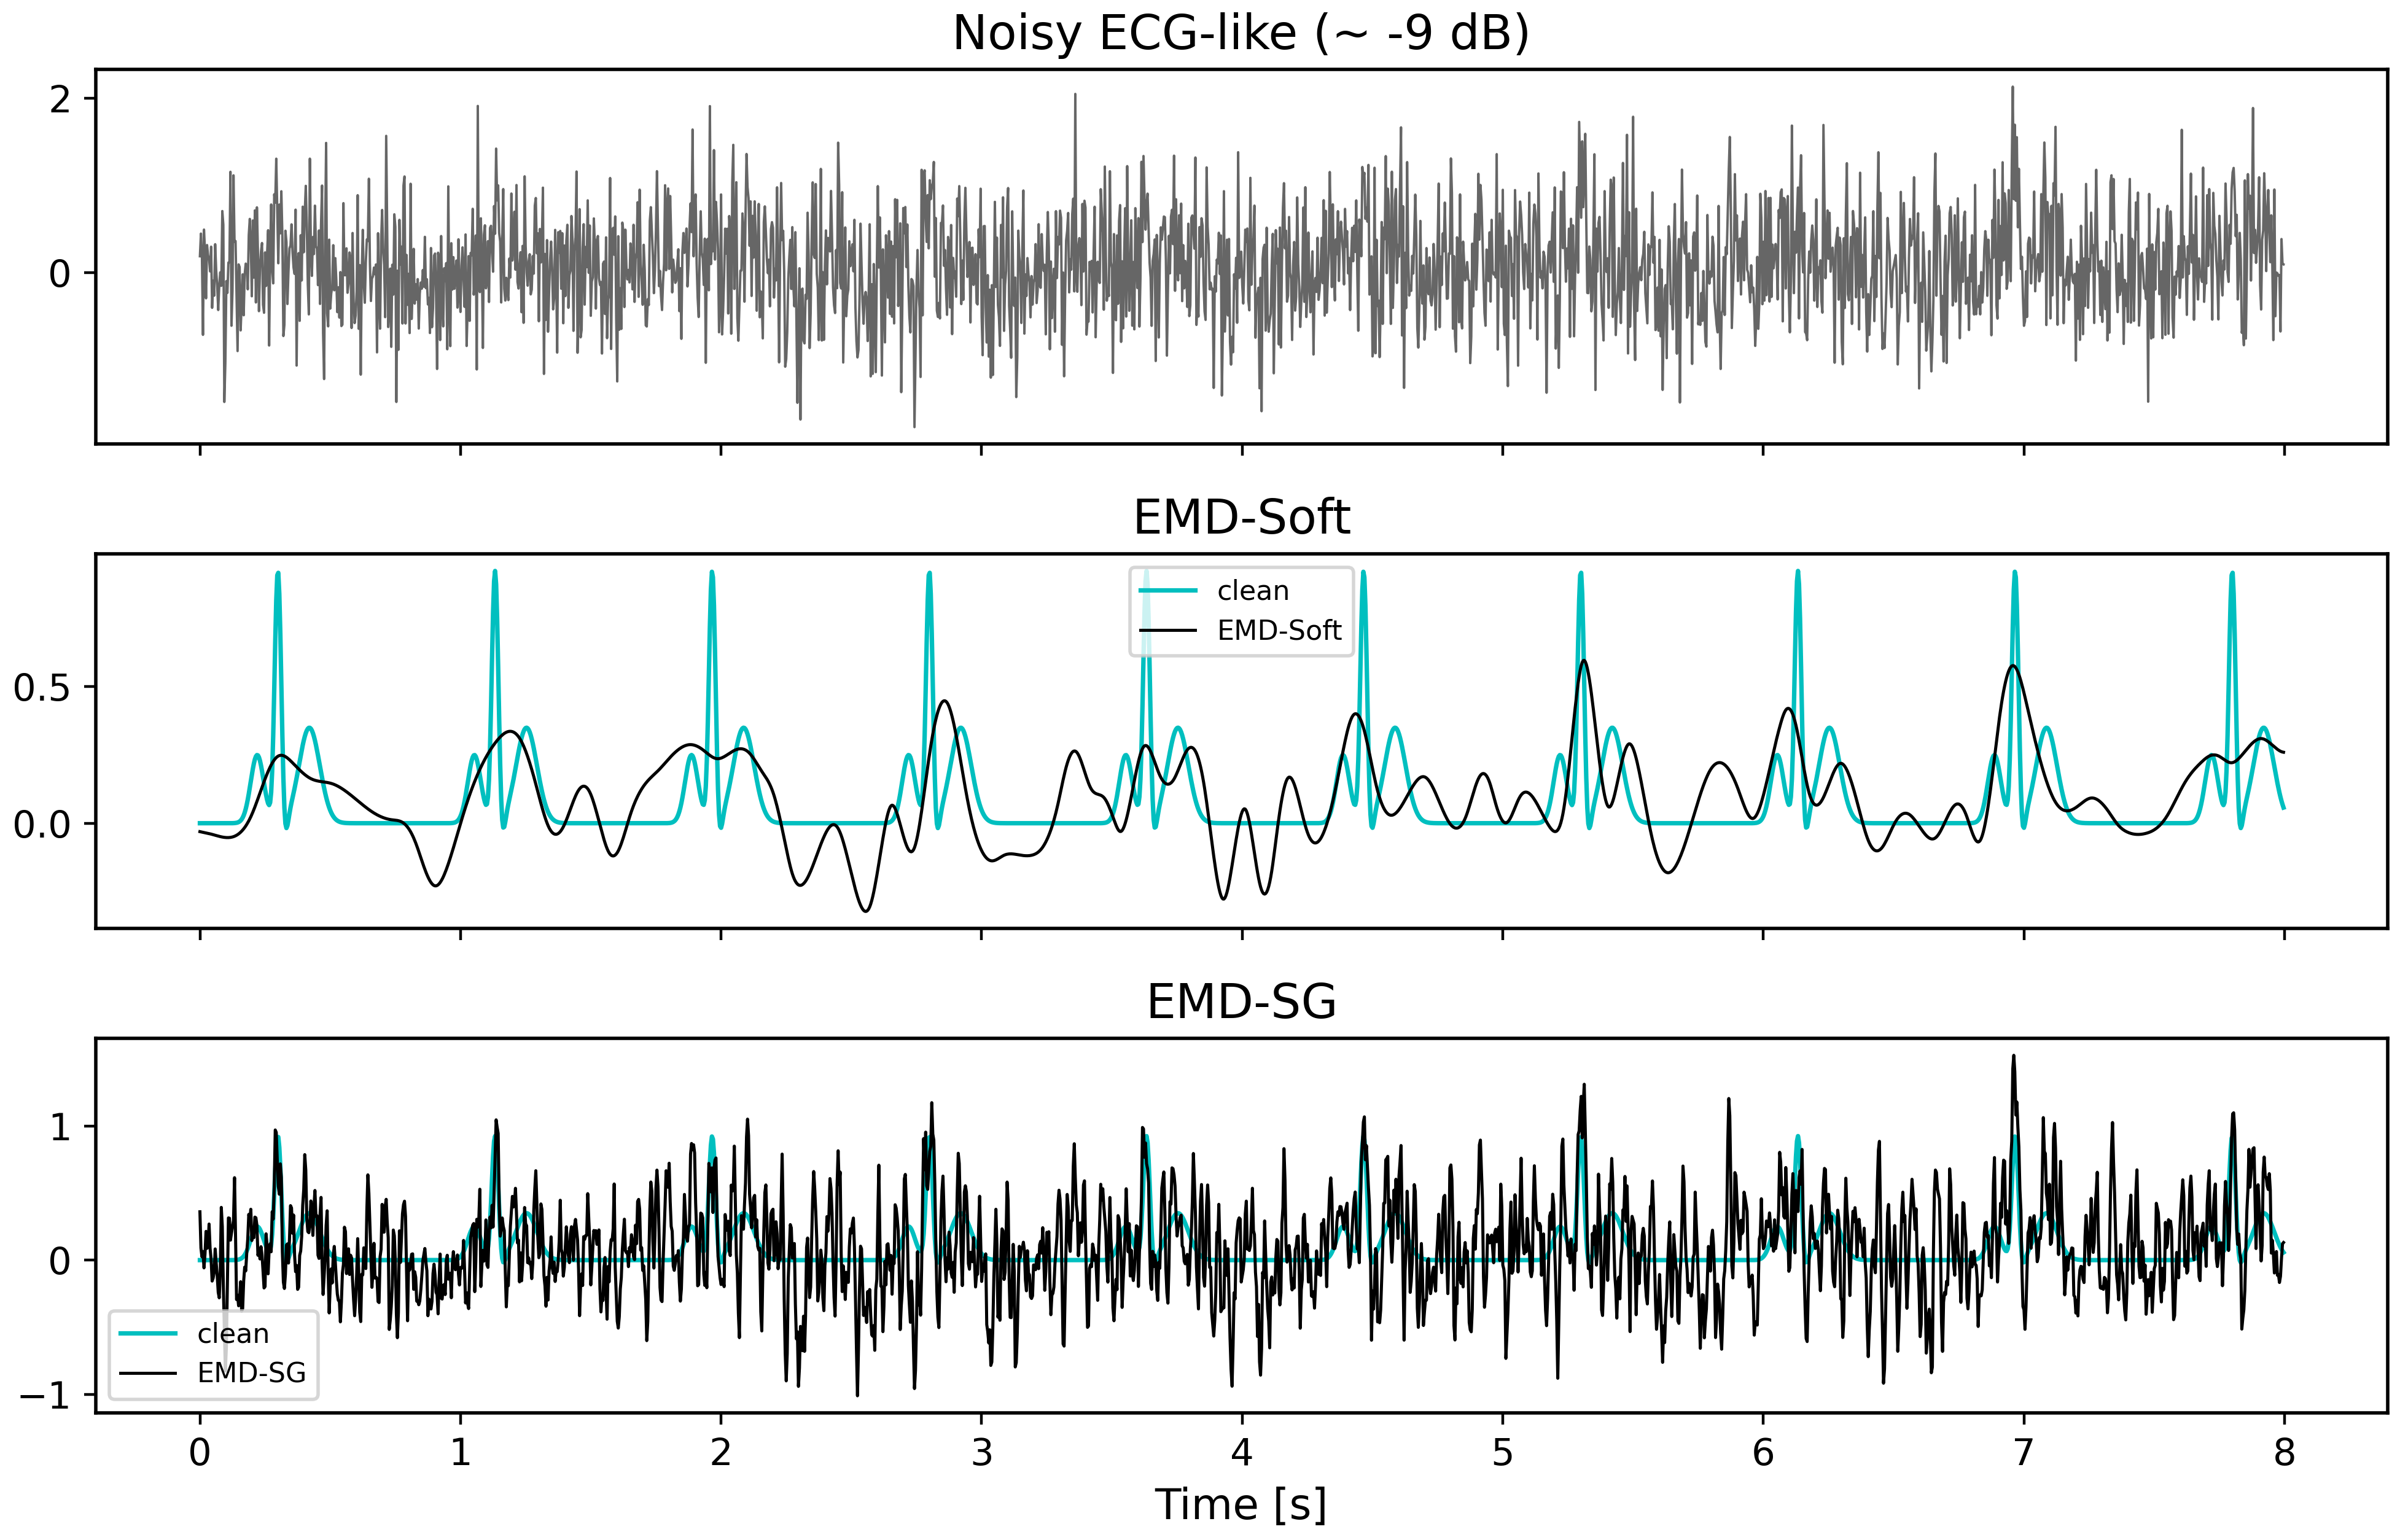

In [8]:
def synthetic_ecg(n=2048, fs=256.0, bpm=72.0):
    t = np.arange(n) / fs
    hr = bpm / 60.0
    x = np.zeros(n)
    period = 1.0 / hr
    for c in np.arange(0.3, t[-1], period):
        x += 1.00 * np.exp(-0.5 * ((t - c) / 0.015) ** 2)
        x += 0.25 * np.exp(-0.5 * ((t - (c - 0.08)) / 0.025) ** 2)
        x += 0.35 * np.exp(-0.5 * ((t - (c + 0.12)) / 0.04) ** 2)
        x -= 0.15 * np.exp(-0.5 * ((t - (c - 0.02)) / 0.01) ** 2)
        x -= 0.25 * np.exp(-0.5 * ((t - (c + 0.02)) / 0.012) ** 2)
    return t, x


t_e, x_e = synthetic_ecg()
y_e = add_awgn(x_e, target_snr_db=-9.0, rng=np.random.default_rng(1))
out_soft = emd_denoise(y_e, method="soft", noise_rule="from_imf1", n_noise_imfs=4)
out_sg = emd_denoise(
    y_e, method="sg", noise_rule="from_imf1", n_noise_imfs=4, window=7, polyorder=3
)

print(f"ECG-like input SNR:  {snr_db(x_e, y_e):.2f} dB")
print(f'EMD-Soft output SNR: {snr_db(x_e, out_soft["recon"]):.2f} dB')
print(f'EMD-SG   output SNR: {snr_db(x_e, out_sg["recon"]):.2f} dB')

fig, axs = plt.subplots(3, 1, figsize=(10, 6.5), sharex=True)
axs[0].plot(t_e, y_e, color="0.4", lw=0.7)
axs[0].set_title("Noisy ECG-like (~ -9 dB)")
axs[1].plot(t_e, x_e, "c", lw=1.3, label="clean")
axs[1].plot(t_e, out_soft["recon"], "k", lw=0.9, label="EMD-Soft")
axs[1].legend(fontsize=8)
axs[1].set_title("EMD-Soft")
axs[2].plot(t_e, x_e, "c", lw=1.3, label="clean")
axs[2].plot(t_e, out_sg["recon"], "k", lw=0.9, label="EMD-SG")
axs[2].legend(fontsize=8)
axs[2].set_title("EMD-SG")
axs[2].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

## 10. Summary

**Paper pipeline**

1. EMD decompose noisy $y$  
2. Preprocess IMFs with $\Gamma$ (threshold / SG / median / average)  
3. Reconstruct $\tilde x=\sum\tilde f_j+r$

**Implementation tips**

- Prefer estimating $\tilde\sigma$ from **IMF$_1$** and processing only early IMFs (`from_imf1` / `cmse`)  
- Literal per-IMF MAD thresholds often over-shrink signal-dominated modes  
- EMD-SG is strong when local polynomial smoothing fits the IMF morphology  
- Absolute SNRs differ from Table I across EMD codes; relative ranking is the useful check

### Minimal pattern

```python
from pysdkit import EMD
# see emd_denoise(...) in this notebook
out = emd_denoise(noisy, method='soft', noise_rule='from_imf1', n_noise_imfs=4)
x_hat = out['recon']
```

### Related notebooks

- `examples/emd.ipynb` — full sifting visualization  
- `examples/hht.ipynb` — Hilbert spectrum after EMD  
